# Diversified ETF Rotation Backtest

This notebook implements a transparent weekly ETF rotation process:

`Momentum → own-trend eligibility → ranking → hysteresis/Top-N selection → inverse-volatility weights → portfolio volatility target → next-session execution`

**Timing rule:** every signal uses data available at the signal session's close. Target weights are first applied to the **next trading session's return**. Positions drift between rebalances, and transaction costs are charged when the next-session rebalance is executed.

Rank-buffer logic is intentionally explicit: eligible incumbents ranked at or above `EXIT_RANK` are retained first; remaining slots are filled by non-held ETFs whose entry rank is at or above `TOP_N`. Trend failure removes an incumbent immediately at the next execution. With hysteresis disabled, the highest-ranked `TOP_N` eligible ETFs are selected.

When fewer than `TOP_N` risky ETFs are selected, the initial risky sleeve is `selected_count / TOP_N`; the remainder is cash. Volatility targeting scales that sleeve. If scaling raises risky exposure above 100%, the cash weight is negative and represents financing at the `CASH_ETF` return; gross exposure is reported rather than hidden.

**Optional high-volatility overlay:** after inverse-volatility weighting and portfolio volatility targeting, each selected ETF's current realized volatility is compared with its prior rolling-median volatility reference. A triggered ETF's final allocation is multiplied by `HIGH_VOL_WEIGHT_MULTIPLIER`, and the released weight is assigned to `CASH_ETF`. The overlay does not renormalize the remaining risky positions, so it intentionally reduces portfolio risk. All inputs are known at the signal close, and the adjusted target still begins on the next session.

The universe is user supplied, so results inherit the usual survivorship assumptions of that list. Correlation and benchmark regimes are diagnostics only and never alter allocations. Robustness checks vary one parameter at a time and are not an optimization or a trading recommendation.


In [154]:
import warnings
from dataclasses import dataclass, replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.4f}".format


In [155]:
# -------------------- User configuration --------------------
ETF_UNIVERSE = [
    # "SPY",
    "QQQ",
    # "IWM",
    "ACWI",
    # "EEM",
    "TLT",
    # "IEF",
    # "TIP",
    "GLD",
    # "DBC",
    "VNQ",
]

BENCHMARK_ETF = "QQQ"
CASH_ETF = "BIL"

START_DATE = "2007-01-01"
END_DATE = None

REBALANCE_FREQUENCY = "M"

TOP_N = 2
EXIT_RANK = 5

MOMENTUM_LOOKBACKS = [63, 126, 252]
MOMENTUM_WEIGHTS = [0.50, 0.30, 0.20]

TREND_MA = 150

VOL_LOOKBACK = 20
TARGET_VOL = 0.2
MAX_GROSS_EXPOSURE = 1.0

# Optional high-volatility allocation adjustment.
HIGH_VOL_ADJUSTMENT_ENABLED = True
HIGH_VOL_THRESHOLD = 1.20  # current vol >= 120% of reference vol
HIGH_VOL_WEIGHT_MULTIPLIER = 0.70  # retain 70% of a triggered ETF's allocation
HIGH_VOL_REFERENCE_LOOKBACK = 252  # rolling median volatility reference

USE_EMA_SMOOTHING = True
EMA_ALPHA = 0.30

TRANSACTION_COST_BPS = 5
RISK_FREE_RATE = 0.0


In [156]:
@dataclass(frozen=True)
class BacktestConfig:
    universe: tuple
    benchmark: str
    cash: str
    start: str
    end: object
    rebalance_frequency: str
    top_n: int
    exit_rank: int
    momentum_lookbacks: tuple
    momentum_weights: tuple
    trend_ma: int
    vol_lookback: int
    target_vol: float
    max_gross_exposure: float
    high_vol_adjustment_enabled: bool
    high_vol_threshold: float
    high_vol_weight_multiplier: float
    high_vol_reference_lookback: int
    use_ema_smoothing: bool
    ema_alpha: float
    transaction_cost_bps: float
    risk_free_rate: float
    use_hysteresis: bool = True

CONFIG = BacktestConfig(
    universe=tuple(ETF_UNIVERSE),
    benchmark=BENCHMARK_ETF,
    cash=CASH_ETF,
    start=START_DATE,
    end=END_DATE,
    rebalance_frequency=REBALANCE_FREQUENCY,
    top_n=TOP_N,
    exit_rank=EXIT_RANK,
    momentum_lookbacks=tuple(MOMENTUM_LOOKBACKS),
    momentum_weights=tuple(MOMENTUM_WEIGHTS),
    trend_ma=TREND_MA,
    vol_lookback=VOL_LOOKBACK,
    target_vol=TARGET_VOL,
    max_gross_exposure=MAX_GROSS_EXPOSURE,
    high_vol_adjustment_enabled=HIGH_VOL_ADJUSTMENT_ENABLED,
    high_vol_threshold=HIGH_VOL_THRESHOLD,
    high_vol_weight_multiplier=HIGH_VOL_WEIGHT_MULTIPLIER,
    high_vol_reference_lookback=HIGH_VOL_REFERENCE_LOOKBACK,
    use_ema_smoothing=USE_EMA_SMOOTHING,
    ema_alpha=EMA_ALPHA,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    risk_free_rate=RISK_FREE_RATE,
)

def validate_config(cfg):
    if len(cfg.momentum_lookbacks) != len(cfg.momentum_weights):
        raise ValueError("MOMENTUM_LOOKBACKS and MOMENTUM_WEIGHTS must have equal length.")
    if not np.isclose(sum(cfg.momentum_weights), 1.0):
        raise ValueError("MOMENTUM_WEIGHTS must sum to 1.0.")
    if cfg.top_n < 1 or cfg.exit_rank < cfg.top_n:
        raise ValueError("Require TOP_N >= 1 and EXIT_RANK >= TOP_N.")
    if not 0 < cfg.ema_alpha <= 1:
        raise ValueError("EMA_ALPHA must be in (0, 1].")
    if cfg.target_vol <= 0 or cfg.max_gross_exposure <= 0:
        raise ValueError("Volatility target and exposure cap must be positive.")
    if cfg.high_vol_threshold <= 0:
        raise ValueError("HIGH_VOL_THRESHOLD must be positive.")
    if not 0 < cfg.high_vol_weight_multiplier <= 1:
        raise ValueError("HIGH_VOL_WEIGHT_MULTIPLIER must be in (0, 1].")
    if cfg.high_vol_reference_lookback < cfg.vol_lookback:
        raise ValueError("HIGH_VOL_REFERENCE_LOOKBACK must be at least VOL_LOOKBACK.")
    if len(cfg.universe) == 0:
        raise ValueError("ETF_UNIVERSE cannot be empty.")

validate_config(CONFIG)
CONFIG


BacktestConfig(universe=('QQQ', 'ACWI', 'TLT', 'GLD', 'VNQ'), benchmark='QQQ', cash='BIL', start='2007-01-01', end=None, rebalance_frequency='M', top_n=2, exit_rank=5, momentum_lookbacks=(63, 126, 252), momentum_weights=(0.5, 0.3, 0.2), trend_ma=150, vol_lookback=20, target_vol=0.2, max_gross_exposure=1.0, high_vol_adjustment_enabled=True, high_vol_threshold=1.2, high_vol_weight_multiplier=0.7, high_vol_reference_lookback=252, use_ema_smoothing=True, ema_alpha=0.3, transaction_cost_bps=5, risk_free_rate=0.0, use_hysteresis=True)

In [157]:
def download_prices(cfg):
    """Download auto-adjusted Yahoo daily closes, preserving pre-inception NaNs."""
    tickers = list(dict.fromkeys([*cfg.universe, cfg.benchmark, cfg.cash]))
    raw = yf.download(
        tickers=tickers,
        start=cfg.start,
        end=cfg.end,
        interval="1d",
        auto_adjust=True,
        group_by="column",
        progress=False,
        threads=True,
    )
    if raw.empty:
        raise RuntimeError("Yahoo Finance returned no data.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            close = raw.xs("Close", axis=1, level=0)
        elif "Close" in raw.columns.get_level_values(1):
            close = raw.xs("Close", axis=1, level=1)
        else:
            raise KeyError("Could not locate the Close field in yfinance output.")
    else:
        if "Close" not in raw.columns:
            raise KeyError("Could not locate the Close field in yfinance output.")
        close = raw[["Close"]].rename(columns={"Close": tickers[0]})

    close = close.reindex(columns=tickers).sort_index()
    close.index = pd.to_datetime(close.index).tz_localize(None)
    close = close.loc[~close.index.duplicated(keep="last")]
    close = close.apply(pd.to_numeric, errors="coerce")
    close = close.dropna(how="all")  # Never forward-fill; pre-inception NaNs remain.

    coverage = pd.DataFrame({
        "First Valid Date": close.apply(lambda s: s.first_valid_index()),
        "Last Valid Date": close.apply(lambda s: s.last_valid_index()),
        "Observations": close.count().astype(int),
    })
    return close, coverage


def calculate_momentum(prices, cfg):
    components = {
        lookback: prices.loc[:, cfg.universe].pct_change(lookback, fill_method=None)
        for lookback in cfg.momentum_lookbacks
    }
    raw = sum(
        weight * components[lookback]
        for lookback, weight in zip(cfg.momentum_lookbacks, cfg.momentum_weights)
    )
    # adjust=False is a recursive, historical-only EMA; NaNs remain until raw momentum exists.
    smoothed = raw.ewm(alpha=cfg.ema_alpha, adjust=False, min_periods=1).mean()
    ranking = smoothed if cfg.use_ema_smoothing else raw.copy()
    return {"components": components, "momentum_score": raw,
            "smoothed_score": smoothed, "ranking_score": ranking}


def calculate_trend_filter(prices, cfg):
    universe_prices = prices.loc[:, cfg.universe]
    moving_average = universe_prices.rolling(cfg.trend_ma, min_periods=cfg.trend_ma).mean()
    eligible = universe_prices.gt(moving_average) & universe_prices.notna()
    return moving_average, eligible


def calculate_volatility(prices, cfg):
    returns = prices.loc[:, cfg.universe].pct_change(fill_method=None)
    annualized = returns.rolling(cfg.vol_lookback, min_periods=cfg.vol_lookback).std() * np.sqrt(252)
    return returns, annualized


def prepare_research_data(prices, cfg):
    momentum = calculate_momentum(prices, cfg)
    moving_average, trend = calculate_trend_filter(prices, cfg)
    risky_returns, volatility = calculate_volatility(prices, cfg)
    # Compare current realized vol with a trailing median that ends one session earlier.
    # min_periods=VOL_LOOKBACK allows the reference to form without delaying the
    # strategy for an additional full reference window.
    high_vol_reference = volatility.rolling(
        cfg.high_vol_reference_lookback, min_periods=cfg.vol_lookback
    ).median().shift(1)
    high_vol_ratio = volatility.div(high_vol_reference.replace(0.0, np.nan))
    high_vol_trigger = high_vol_ratio.ge(cfg.high_vol_threshold).fillna(False)
    if not cfg.high_vol_adjustment_enabled:
        high_vol_trigger.loc[:, :] = False
    # Eligibility requires every configured horizon plus trend and volatility history.
    valid_history = (
        momentum["ranking_score"].notna()
        & volatility.notna()
        & prices.loc[:, cfg.universe].notna()
    )
    eligibility = trend & valid_history
    return {
        **momentum,
        "moving_average": moving_average,
        "trend_filter": trend,
        "eligibility": eligibility,
        "risky_returns": risky_returns,
        "realized_volatility": volatility,
        "high_vol_reference": high_vol_reference,
        "high_vol_ratio": high_vol_ratio,
        "high_vol_trigger": high_vol_trigger,
    }


In [158]:
def _weekly_signal_dates(index, frequency):
    # Resampling a Series of actual sessions returns each period's last available session.
    sessions = pd.Series(index, index=index)
    return pd.DatetimeIndex(sessions.resample(frequency).last().dropna().values)


def generate_weekly_selection(research, prices, cfg):
    """Return weekly ranks and selections using close-of-signal-date information only."""
    signal_dates = _weekly_signal_dates(prices.index, cfg.rebalance_frequency)
    previous = []
    records = []

    for date in signal_dates:
        eligible_names = [
            ticker for ticker in cfg.universe
            if bool(research["eligibility"].at[date, ticker])
        ]
        score = research["ranking_score"].loc[date, eligible_names].dropna()
        ordered = score.sort_values(ascending=False, kind="mergesort")
        ranks = pd.Series(np.arange(1, len(ordered) + 1), index=ordered.index, dtype=int)

        if cfg.use_hysteresis:
            # Retained incumbents get priority; trend failures are absent from ranks.
            retained = sorted(
                [ticker for ticker in previous
                 if ticker in ranks.index and ranks[ticker] <= cfg.exit_rank],
                key=lambda ticker: ranks[ticker],
            )
            entrants = [
                ticker for ticker in ordered.index
                if ranks[ticker] <= cfg.top_n and ticker not in retained
            ]
            selected = (retained + entrants)[:cfg.top_n]
        else:
            selected = list(ordered.index[:cfg.top_n])

        previous = selected
        records.append({
            "Signal Date": date,
            "Selected": tuple(selected),
            "Ranks": ranks.to_dict(),
            "Scores": ordered.to_dict(),
        })

    return pd.DataFrame(records).set_index("Signal Date")


def apply_high_vol_adjustment(risky_weights, date, research, cfg):
    """Reduce triggered ETF weights after vol targeting; send reduction to cash."""
    adjusted = risky_weights.copy()
    if adjusted.empty or not cfg.high_vol_adjustment_enabled:
        return adjusted, tuple(), 0.0
    flags = research["high_vol_trigger"].loc[date, adjusted.index].fillna(False)
    triggered = tuple(flags.index[flags])
    if not triggered:
        return adjusted, tuple(), 0.0
    before = float(adjusted.sum())
    adjusted.loc[list(triggered)] *= cfg.high_vol_weight_multiplier
    reduction = before - float(adjusted.sum())
    return adjusted, triggered, reduction


def calculate_weights(selected, date, research, cfg):
    """Inverse-vol weights and covariance-based portfolio vol, all ending at signal close."""
    selected = list(selected)
    if not selected:
        return pd.Series(dtype=float), np.nan, np.nan, np.nan, tuple(), 0.0

    window = research["risky_returns"].loc[:date, selected].tail(cfg.vol_lookback)
    valid = [
        ticker for ticker in selected
        if window[ticker].count() >= cfg.vol_lookback
        and np.isfinite(window[ticker].std())
        and window[ticker].std() * np.sqrt(252) > 1e-4
    ]
    if not valid:
        return pd.Series(dtype=float), np.nan, np.nan, np.nan, tuple(), 0.0

    window = window[valid].dropna()
    if len(window) < cfg.vol_lookback:
        return pd.Series(dtype=float), np.nan, np.nan, np.nan, tuple(), 0.0

    annual_vol = window.std(ddof=1) * np.sqrt(252)
    inverse_vol = 1.0 / annual_vol.clip(lower=1e-4)
    normalized = inverse_vol / inverse_vol.sum()

    # Missing selections reserve slots for cash before volatility scaling.
    sleeve_fraction = min(len(valid) / cfg.top_n, 1.0)
    preliminary = normalized * sleeve_fraction
    covariance = window.cov().to_numpy()
    estimated_vol = float(
        np.sqrt(preliminary.to_numpy() @ covariance @ preliminary.to_numpy()) * np.sqrt(252)
    )
    scalar = (
        min(cfg.target_vol / estimated_vol, cfg.max_gross_exposure)
        if np.isfinite(estimated_vol) and estimated_vol > 1e-8
        else 0.0
    )
    risky_weights = preliminary * scalar
    risky_weights, triggered, reduction = apply_high_vol_adjustment(
        risky_weights, date, research, cfg
    )
    return risky_weights, estimated_vol, scalar, sleeve_fraction, triggered, reduction


def apply_vol_target(selection, research, prices, cfg):
    """Build signal-close targets; execution is deliberately handled separately."""
    columns = list(dict.fromkeys([*cfg.universe, cfg.cash]))
    targets = pd.DataFrame(0.0, index=selection.index, columns=columns)
    diagnostics = []

    for date, row in selection.iterrows():
        risky, estimated_vol, scalar, sleeve, high_vol_etfs, high_vol_reduction = calculate_weights(
            row["Selected"], date, research, cfg
        )
        if len(risky):
            targets.loc[date, risky.index] = risky
        risky_exposure = float(risky.sum()) if len(risky) else 0.0
        # Negative cash is an explicit financing position when risky exposure > 100%.
        targets.loc[date, cfg.cash] = 1.0 - risky_exposure

        corr_window = research["risky_returns"].loc[:date, list(risky.index)].tail(cfg.vol_lookback)
        corr = corr_window.corr() if len(risky) >= 2 else pd.DataFrame()
        if len(risky) >= 2:
            upper = corr.to_numpy()[np.triu_indices(len(corr), k=1)]
            avg_corr = float(np.nanmean(upper)) if np.isfinite(upper).any() else np.nan
            max_corr = float(np.nanmax(upper)) if np.isfinite(upper).any() else np.nan
        else:
            avg_corr = max_corr = np.nan

        diagnostics.append({
            "Signal Date": date,
            "Selected Count": len(risky),
            "Estimated Portfolio Vol": estimated_vol,
            "Vol Scalar": scalar,
            "Initial Risky Sleeve": sleeve,
            "Gross Risky Exposure": risky_exposure,
            "High-Vol ETFs": high_vol_etfs,
            "High-Vol Weight Reduction": high_vol_reduction,
            "Average Pairwise Correlation": avg_corr,
            "Maximum Pairwise Correlation": max_corr,
        })

    return targets, pd.DataFrame(diagnostics).set_index("Signal Date")


In [159]:
def _map_targets_to_next_session(targets, trading_index):
    """Map every close-of-day signal target to the strictly following trading session."""
    execution = {}
    for signal_date, row in targets.iterrows():
        position = trading_index.searchsorted(signal_date, side="right")
        if position < len(trading_index):
            execution[trading_index[position]] = row
    if not execution:
        return pd.DataFrame(columns=targets.columns, dtype=float)
    return pd.DataFrame(execution).T.sort_index()


def run_backtest(prices, cfg, research=None):
    validate_config(cfg)
    research = prepare_research_data(prices, cfg) if research is None else research
    selection = generate_weekly_selection(research, prices, cfg)
    signal_targets, signal_diagnostics = apply_vol_target(
        selection, research, prices, cfg
    )
    execution_targets = _map_targets_to_next_session(signal_targets, prices.index)

    assets = list(signal_targets.columns)
    asset_returns = prices[assets].pct_change(fill_method=None)
    active_weights = pd.DataFrame(np.nan, index=prices.index, columns=assets)
    strategy_returns = pd.Series(np.nan, index=prices.index, name="Rotation Strategy")
    turnover = pd.Series(0.0, index=prices.index, name="Turnover")
    costs = pd.Series(0.0, index=prices.index, name="Transaction Costs")
    cost_rate = cfg.transaction_cost_bps / 10_000.0

    current = pd.Series(0.0, index=assets)
    current[cfg.cash] = 1.0
    started = False

    for date in prices.index:
        if date in execution_targets.index:
            target = execution_targets.loc[date].astype(float)
            turnover.at[date] = 0.5 * float((target - current).abs().sum())
            costs.at[date] = turnover.at[date] * cost_rate
            current = target.copy()
            started = True

        if not started:
            continue

        day_returns = asset_returns.loc[date]
        required = current.abs() > 1e-12
        if day_returns[required].isna().any():
            continue

        active_weights.loc[date] = current
        gross_return = float((current * day_returns.fillna(0.0)).sum())
        strategy_returns.at[date] = gross_return - costs.at[date]

        # Let holdings drift after the session; next execution trades from these weights.
        denominator = 1.0 + gross_return
        if denominator > 1e-12:
            current = current * (1.0 + day_returns.fillna(0.0)) / denominator

    gross_exposure = active_weights[list(cfg.universe)].clip(lower=0).sum(axis=1, min_count=1)
    risky_count = (active_weights[list(cfg.universe)].abs() > 1e-10).sum(axis=1)
    risky_count = risky_count.where(active_weights.notna().any(axis=1))
    correlation_daily = signal_diagnostics["Average Pairwise Correlation"].reindex(
        prices.index
    ).ffill()
    first_execution = execution_targets.index.min() if len(execution_targets) else None
    if first_execution is not None:
        correlation_daily.loc[correlation_daily.index < first_execution] = np.nan

    return {
        "config": cfg,
        "research": research,
        "selection": selection,
        "signal_targets": signal_targets,
        "execution_targets": execution_targets,
        "signal_diagnostics": signal_diagnostics,
        "active_weights": active_weights,
        "returns": strategy_returns,
        "turnover": turnover,
        "costs": costs,
        "gross_exposure": gross_exposure,
        "risky_count": risky_count,
        "correlation_daily": correlation_daily,
    }


In [160]:
def calculate_metrics(returns, risk_free_rate=0.0):
    returns = pd.Series(returns).dropna()
    if returns.empty:
        return {key: np.nan for key in [
            "CAGR", "Annualized Volatility", "Sharpe", "Sortino",
            "Maximum Drawdown", "Calmar", "Total Return"
        ]}
    growth = (1.0 + returns).cumprod()
    years = len(returns) / 252.0
    total_return = float(growth.iloc[-1] - 1.0)
    cagr = float(growth.iloc[-1] ** (1.0 / years) - 1.0) if years > 0 else np.nan
    volatility = float(returns.std(ddof=1) * np.sqrt(252))
    excess = returns - risk_free_rate / 252.0
    sharpe = float(excess.mean() / returns.std(ddof=1) * np.sqrt(252)) if returns.std(ddof=1) > 0 else np.nan
    downside = np.sqrt(np.mean(np.minimum(excess, 0.0) ** 2)) * np.sqrt(252)
    sortino = float(excess.mean() * 252 / downside) if downside > 0 else np.nan
    drawdown = growth / growth.cummax() - 1.0
    max_drawdown = float(drawdown.min())
    calmar = cagr / abs(max_drawdown) if max_drawdown < 0 else np.nan
    return {
        "CAGR": cagr,
        "Annualized Volatility": volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Maximum Drawdown": max_drawdown,
        "Calmar": calmar,
        "Total Return": total_return,
    }


def align_strategy_and_benchmark(result, prices):
    strategy = result["returns"].dropna()
    benchmark = prices[result["config"].benchmark].pct_change(fill_method=None)
    common = pd.concat(
        [strategy, benchmark.rename("Benchmark Buy & Hold")], axis=1
    ).dropna()
    common.columns = ["Rotation Strategy", "Benchmark Buy & Hold"]
    return common


def performance_comparison(result, prices):
    cfg = result["config"]
    common = align_strategy_and_benchmark(result, prices)
    table = pd.DataFrame({
        name: calculate_metrics(common[name], cfg.risk_free_rate)
        for name in common.columns
    }).T
    years = len(common) / 252.0
    strategy_mask = common.index
    table.loc["Rotation Strategy", "Average Gross Exposure"] = result["gross_exposure"].reindex(strategy_mask).mean()
    table.loc["Rotation Strategy", "Maximum Gross Exposure"] = result["gross_exposure"].reindex(strategy_mask).max()
    table.loc["Rotation Strategy", "Average Risky ETFs Held"] = result["risky_count"].reindex(strategy_mask).mean()
    table.loc["Rotation Strategy", "Time 100% Cash"] = (
        result["gross_exposure"].reindex(strategy_mask).fillna(0).abs() < 1e-10
    ).mean()
    table.loc["Rotation Strategy", "Total Turnover"] = result["turnover"].reindex(strategy_mask).sum()
    table.loc["Rotation Strategy", "Annual Turnover"] = table.loc["Rotation Strategy", "Total Turnover"] / years
    table.loc["Rotation Strategy", "Cumulative Transaction Costs"] = result["costs"].reindex(strategy_mask).sum()
    return table, common


def drawdown_series(returns):
    growth = (1.0 + returns).cumprod()
    return growth / growth.cummax() - 1.0


In [161]:
prices, data_coverage = download_prices(CONFIG)

print("Yahoo Finance adjusted-close coverage (no pre-inception forward fill):")
display(data_coverage)

missing = data_coverage.index[data_coverage["Observations"].eq(0)].tolist()
if missing:
    raise RuntimeError(f"No Yahoo price observations for: {missing}")

research = prepare_research_data(prices, CONFIG)
full_result = run_backtest(prices, CONFIG, research=research)
performance_table, common_returns = performance_comparison(full_result, prices)

print(
    f"Common backtest period: {common_returns.index.min().date()} to "
    f"{common_returns.index.max().date()} ({len(common_returns):,} sessions)"
)
display(performance_table.style.format({
    "CAGR": "{:.2%}", "Annualized Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}", "Maximum Drawdown": "{:.2%}", "Calmar": "{:.2f}",
    "Total Return": "{:.2%}", "Average Gross Exposure": "{:.2%}",
    "Maximum Gross Exposure": "{:.2%}", "Average Risky ETFs Held": "{:.2f}",
    "Time 100% Cash": "{:.2%}", "Total Turnover": "{:.2f}x",
    "Annual Turnover": "{:.2%}",
    "Cumulative Transaction Costs": "{:.2%}",
}))


Yahoo Finance adjusted-close coverage (no pre-inception forward fill):


,First Valid Date,Last Valid Date,Observations
Ticker,,,
QQQ,2007-01-03,2026-09-23,4962
ACWI,2008-03-28,2026-09-23,4651
TLT,2007-01-03,2026-09-23,4962
GLD,2007-01-03,2026-09-23,4962
VNQ,2007-01-03,2026-09-23,4961
BIL,2007-05-30,2026-09-23,4861


Common backtest period: 2007-05-31 to 2026-09-21 (4,858 sessions)


,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,Calmar,Total Return,Average Gross Exposure,Maximum Gross Exposure,Average Risky ETFs Held,Time 100% Cash,Total Turnover,Annual Turnover,Cumulative Transaction Costs
Rotation Strategy,12.77%,11.40%,1.11,1.58,-14.65%,0.87,914.22%,83.37%,100.00%,1.79,7.41%,49.64x,257.49%,2.48%
Benchmark Buy & Hold,16.29%,22.35%,0.79,1.12,-53.40%,0.31,1735.06%,nan%,nan%,nan,nan%,nanx,nan%,nan%


## Research audit trail

The objects below retain raw composite momentum, EMA-smoothed momentum, the score actually ranked, each ETF's own moving average and eligibility, weekly ranks/selections, signal-close targets, and next-session execution targets. Change the sample dates to inspect any decision.


In [162]:
AUDIT_START = full_result["selection"].index.max() - pd.Timedelta(days=35)
AUDIT_END = full_result["selection"].index.max()

audit = full_result["selection"].loc[AUDIT_START:AUDIT_END].copy()
audit["Execution Date"] = [
    prices.index[prices.index.searchsorted(date, side="right")]
    if prices.index.searchsorted(date, side="right") < len(prices.index) else pd.NaT
    for date in audit.index
]
display(audit)
display(pd.concat({
    "Raw Momentum": research["momentum_score"].loc[AUDIT_START:AUDIT_END],
    "EMA Momentum": research["smoothed_score"].loc[AUDIT_START:AUDIT_END],
    "Ranking Score": research["ranking_score"].loc[AUDIT_START:AUDIT_END],
}, axis=1).tail(10))


,Selected,Ranks,Scores,Execution Date
Signal Date,,,,
2026-08-31,"(QQQ, ACWI)","{'QQQ': 1, 'ACWI': 2, 'VNQ': 3}","{'QQQ': 0.09340940532052107, 'ACWI': 0.0873258...",2026-09-01
2026-09-23,"(QQQ,)",{'QQQ': 1},{'QQQ': 0.13061578313218558},NaT


Raw Momentum                                EMA Momentum         \
Ticker              QQQ   ACWI     TLT     GLD     VNQ          QQQ   ACWI   
Date                                                                         
2026-09-10       0.1074 0.0993 -0.0447  0.0161  0.0099       0.1047 0.1005   
2026-09-11       0.1063 0.1027 -0.0503  0.0102  0.0201       0.1052 0.1012   
2026-09-14       0.0953 0.0916 -0.0482 -0.0014  0.0063       0.1022 0.0983   
2026-09-15       0.0682 0.0737 -0.0519 -0.0112  0.0056       0.0920 0.0909   
2026-09-16       0.0739 0.0695 -0.0538 -0.0203 -0.0032       0.0866 0.0845   
2026-09-17       0.1028 0.0933 -0.0428  0.0159  0.0184       0.0915 0.0871   
2026-09-18       0.0992 0.0862 -0.0526  0.0385  0.0104       0.0938 0.0868   
2026-09-21       0.1369 0.1104 -0.0350  0.0444  0.0245       0.1067 0.0939   
2026-09-22       0.1573    NaN -0.0377  0.0631     NaN       0.1219 0.0939   
2026-09-23       0.1510 0.1050 -0.0573  0.0562 -0.0066       0.1306 0.0981   

                                  Ranking Score                                
Ticker         TLT     GLD    VNQ           QQQ   ACWI     TLT     GLD    VNQ  
Date                                                                           
2026-09-10 -0.0369  0.0112 0.0250        0.1047 0.1005 -0.0369  0.0112 0.0250  
2026-09-11 -0.0409  0.0109 0.0235        0.1052 0.1012 -0.0409  0.0109 0.0235  
2026-09-14 -0.0431  0.0072 0.0183        0.1022 0.0983 -0.0431  0.0072 0.0183  
2026-09-15 -0.0458  0.0017 0.0145        0.0920 0.0909 -0.0458  0.0017 0.0145  
2026-09-16 -0.0482 -0.0049 0.0092        0.0866 0.0845 -0.0482 -0.0049 0.0092  
2026-09-17 -0.0466  0.0013 0.0119        0.0915 0.0871 -0.0466  0.0013 0.0119  
2026-09-18 -0.0484  0.0125 0.0115        0.0938 0.0868 -0.0484  0.0125 0.0115  
2026-09-21 -0.0443  0.0221 0.0154        0.1067 0.0939 -0.0443  0.0221 0.0154  
2026-09-22 -0.0424  0.0344 0.0154        0.1219 0.0939 -0.0424  0.0344 0.0154  
2026-09-23 -0.0468  0.0409 0.0070        0.1306 0.0981 -0.0468  0.0409 0.0070

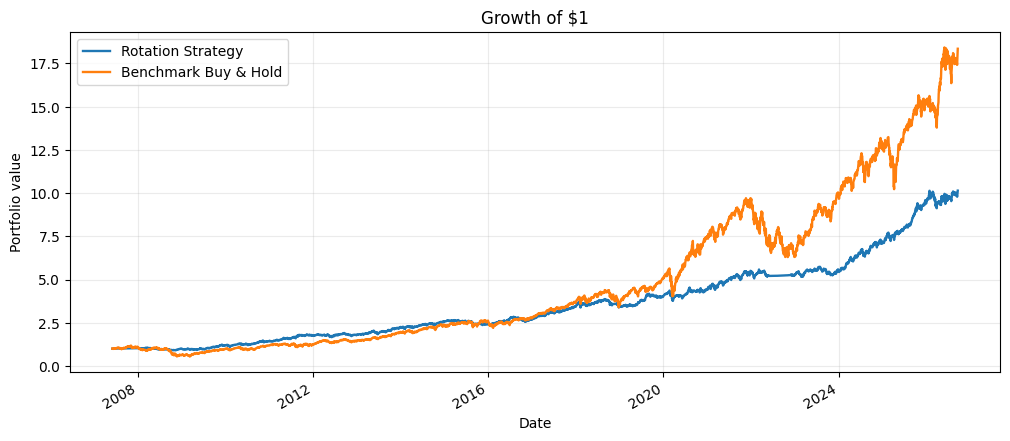

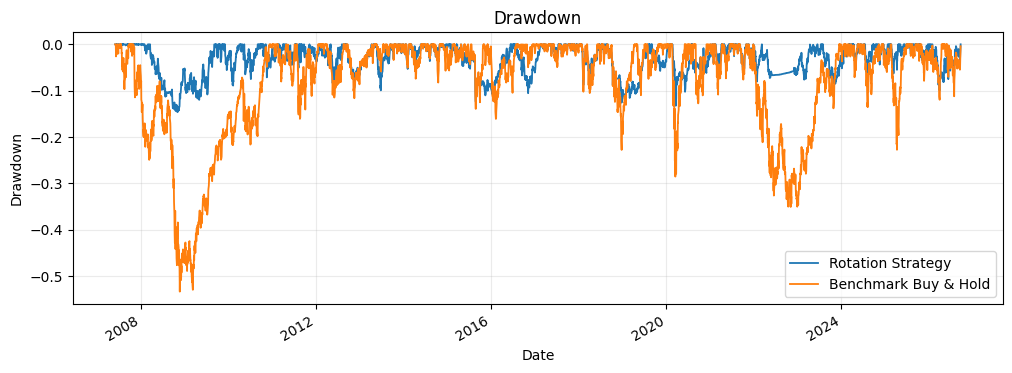

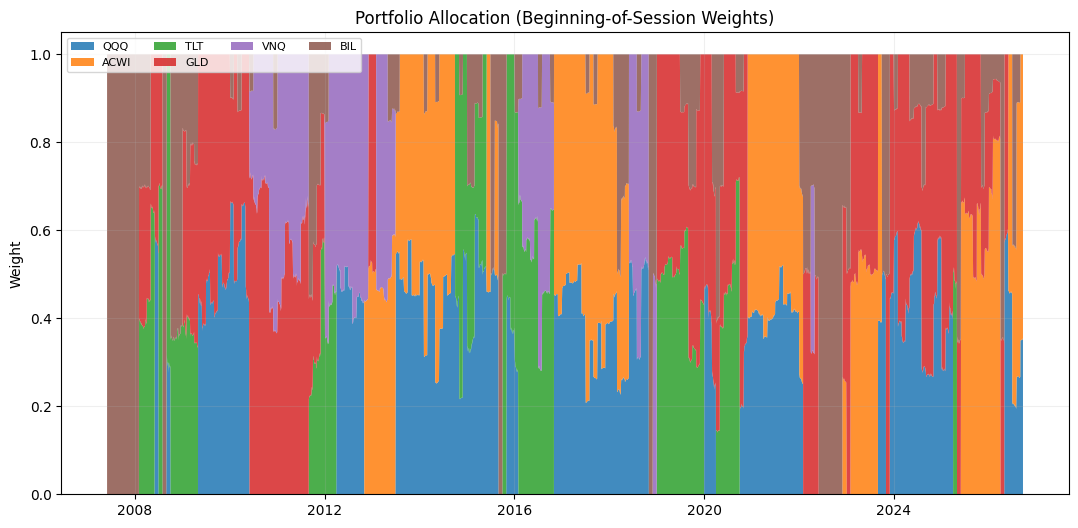

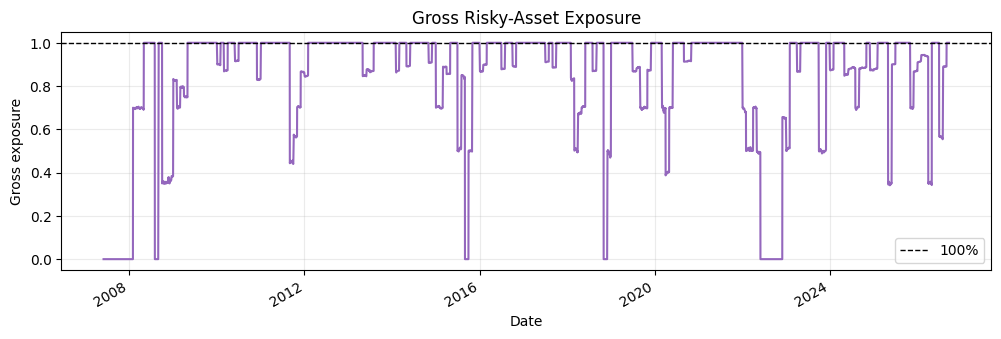

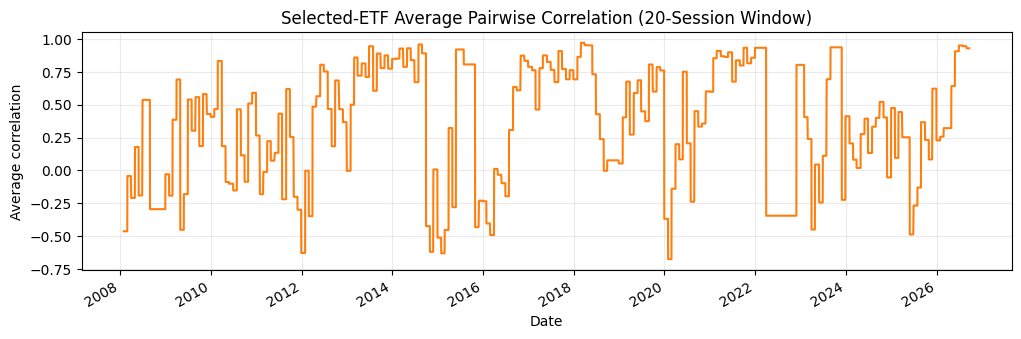

In [163]:
# Equity curves
growth = (1.0 + common_returns).cumprod()
ax = growth.plot(figsize=(12, 5), linewidth=1.7, title="Growth of $1")
ax.set_ylabel("Portfolio value")
ax.grid(alpha=0.25)
plt.show()

# Drawdowns
drawdowns = common_returns.apply(drawdown_series)
ax = drawdowns.plot(figsize=(12, 4), linewidth=1.3, title="Drawdown")
ax.set_ylabel("Drawdown")
ax.grid(alpha=0.25)
plt.show()

# Allocation weights active during each session (negative cash, if present, is financing).
plot_weights = full_result["active_weights"].loc[common_returns.index].dropna(how="all")
fig, ax = plt.subplots(figsize=(13, 6))
positive_weights = plot_weights.clip(lower=0)
ax.stackplot(
    positive_weights.index,
    *[positive_weights[column].values for column in positive_weights.columns],
    labels=positive_weights.columns,
    alpha=0.85,
)
negative_cash = plot_weights[CONFIG.cash].clip(upper=0)
if negative_cash.lt(0).any():
    ax.fill_between(negative_cash.index, negative_cash.values, 0, color="black", alpha=0.35,
                    label=f"{CONFIG.cash} financing")
ax.set_title("Portfolio Allocation (Beginning-of-Session Weights)")
ax.set_ylabel("Weight")
ax.legend(loc="upper left", ncol=4, fontsize=8)
ax.grid(alpha=0.2)
plt.show()

# Gross risky exposure
ax = full_result["gross_exposure"].loc[common_returns.index].plot(
    figsize=(12, 3.5), title="Gross Risky-Asset Exposure", color="tab:purple"
)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="100%")
ax.set_ylabel("Gross exposure")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# Portfolio average pairwise correlation
ax = full_result["correlation_daily"].loc[common_returns.index].plot(
    figsize=(12, 3.5), title=f"Selected-ETF Average Pairwise Correlation ({CONFIG.vol_lookback}-Session Window)",
    color="tab:orange",
)
ax.set_ylabel("Average correlation")
ax.grid(alpha=0.25)
plt.show()


## Correlation diagnostics

Each weekly value is computed from the trailing `VOL_LOOKBACK` daily return matrix of the ETFs actually selected at that signal. Low/high labels use the **prior** expanding median of portfolio average correlation, so the diagnostic classification also avoids a full-sample optimized threshold. Correlation is not a selection input.


In [164]:
def conditional_performance(returns, labels):
    rows = []
    aligned = pd.concat([returns.rename("Return"), labels.rename("Label")], axis=1).dropna()
    for label, group in aligned.groupby("Label"):
        metrics = calculate_metrics(group["Return"], CONFIG.risk_free_rate)
        rows.append({
            "Period": label,
            "Annualized Return": group["Return"].mean() * 252,
            "Annualized Volatility": metrics["Annualized Volatility"],
            "Sharpe": metrics["Sharpe"],
            "Maximum Drawdown": metrics["Maximum Drawdown"],
            "Observations": len(group),
        })
    return pd.DataFrame(rows).set_index("Period") if rows else pd.DataFrame()

portfolio_corr = full_result["correlation_daily"].reindex(common_returns.index)
corr_threshold = portfolio_corr.expanding(min_periods=26).median().shift(1)
corr_label = pd.Series(
    np.where(portfolio_corr <= corr_threshold, "Low Correlation", "High Correlation"),
    index=portfolio_corr.index,
).where(portfolio_corr.notna() & corr_threshold.notna())

correlation_performance = conditional_performance(
    common_returns["Rotation Strategy"], corr_label
)
display(correlation_performance.style.format({
    "Annualized Return": "{:.2%}", "Annualized Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Maximum Drawdown": "{:.2%}",
}))

display(full_result["signal_diagnostics"][[
    "Average Pairwise Correlation", "Maximum Pairwise Correlation"
]].tail(12))


,Annualized Return,Annualized Volatility,Sharpe,Maximum Drawdown,Observations
Period,,,,,
High Correlation,12.89%,11.87%,1.09,-17.75%,2560
Low Correlation,13.14%,11.30%,1.16,-13.67%,2103


,Average Pairwise Correlation,Maximum Pairwise Correlation
Signal Date,,
2025-10-31,0.0839,0.0839
2025-11-28,0.6211,0.6211
2025-12-31,0.2283,0.2283
2026-01-30,0.2565,0.2565
2026-02-27,0.3215,0.3215
2026-03-31,NaN,NaN
2026-04-30,0.6409,0.6409
2026-05-29,0.9050,0.9050
2026-06-30,0.9491,0.9491


In [165]:
# Calendar-year returns over the exact common strategy/benchmark period.
annual_returns = (1.0 + common_returns).resample("Y").prod() - 1.0
annual_returns.index = annual_returns.index.year
annual_returns.index.name = "Year"
annual_returns = annual_returns.rename(columns={
    "Rotation Strategy": "Strategy Return",
    "Benchmark Buy & Hold": "Benchmark Return",
})
annual_returns["Excess Return"] = (
    annual_returns["Strategy Return"] - annual_returns["Benchmark Return"]
)

beat_years = int((annual_returns["Excess Return"] > 0).sum())
underperformed_years = int((annual_returns["Excess Return"] < 0).sum())
positive_year_pct = float((annual_returns["Strategy Return"] > 0).mean())

display(annual_returns.style.format("{:.2%}"))
print(f"Years strategy beat benchmark: {beat_years}")
print(f"Years strategy underperformed benchmark: {underperformed_years}")
print(f"Positive strategy years: {positive_year_pct:.1%}")


,Strategy Return,Benchmark Return,Excess Return
Year,,,
2007,2.50%,8.79%,-6.29%
2008,-2.66%,-41.73%,39.06%
2009,19.19%,54.68%,-35.49%
2010,21.75%,20.14%,1.61%
2011,22.01%,3.48%,18.53%
2012,1.88%,18.11%,-16.23%
2013,25.40%,36.63%,-11.23%
2014,13.29%,19.18%,-5.89%
2015,-6.05%,9.44%,-15.49%


Years strategy beat benchmark: 8
Years strategy underperformed benchmark: 12
Positive strategy years: 85.0%


## Benchmark regime diagnostics

Regimes use only `BENCHMARK_ETF`. The 20-session volatility threshold is its trailing 252-session median (minimum 126 observations). The completed close-of-session regime label is shifted one session before it is paired with strategy returns. These labels are diagnostic and never feed the portfolio.


In [166]:
def calculate_regimes(prices, benchmark, trend_ma=200):
    benchmark_price = prices[benchmark]
    benchmark_return = benchmark_price.pct_change(fill_method=None)
    benchmark_ma = benchmark_price.rolling(trend_ma, min_periods=trend_ma).mean()
    vol20 = benchmark_return.rolling(20, min_periods=20).std() * np.sqrt(252)
    trailing_threshold = vol20.rolling(252, min_periods=126).median()

    trend = pd.Series(
        np.where(benchmark_price > benchmark_ma, "Bull", "Bear"),
        index=prices.index,
    ).where(benchmark_ma.notna())
    volatility = pd.Series(
        np.where(vol20 > trailing_threshold, "High Vol", "Low Vol"),
        index=prices.index,
    ).where(vol20.notna() & trailing_threshold.notna())

    # A return on day t is labeled only with the regime known after day t-1's close.
    regime = (trend + " / " + volatility).shift(1)
    return pd.DataFrame({
        "Benchmark MA": benchmark_ma,
        "Benchmark 20D Vol": vol20,
        "Trailing Vol Median": trailing_threshold,
        "Regime": regime,
    })


def regime_performance(strategy_returns, regime_data, risk_free_rate):
    aligned = pd.concat(
        [strategy_returns.rename("Return"), regime_data["Regime"]], axis=1
    ).dropna()
    rows = []
    expected = [
        "Bull / Low Vol", "Bull / High Vol",
        "Bear / Low Vol", "Bear / High Vol",
    ]
    for regime in expected:
        values = aligned.loc[aligned["Regime"].eq(regime), "Return"]
        metrics = calculate_metrics(values, risk_free_rate)
        rows.append({
            "Regime": regime,
            "Annualized Return": values.mean() * 252 if len(values) else np.nan,
            "Volatility": metrics["Annualized Volatility"],
            "Sharpe": metrics["Sharpe"],
            "Maximum Drawdown": metrics["Maximum Drawdown"],
            "Observations": len(values),
        })
    return pd.DataFrame(rows).set_index("Regime")

regime_data = calculate_regimes(prices, CONFIG.benchmark, trend_ma=200)
regime_table = regime_performance(
    common_returns["Rotation Strategy"], regime_data, CONFIG.risk_free_rate
)
display(regime_table.style.format({
    "Annualized Return": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Maximum Drawdown": "{:.2%}",
}))


,Annualized Return,Volatility,Sharpe,Maximum Drawdown,Observations
Regime,,,,,
Bull / Low Vol,10.29%,11.66%,0.88,-17.57%,2209
Bull / High Vol,17.10%,11.16%,1.53,-9.89%,1624
Bear / Low Vol,21.42%,8.87%,2.42,-2.56%,134
Bear / High Vol,9.78%,12.19%,0.80,-10.94%,793


## Ablation comparison

All four versions use identical data and parameters. Only EMA smoothing and rank hysteresis are toggled, so this is a direct attribution check rather than parameter tuning.


In [167]:
def summarize_run(result, prices):
    comparison, common = performance_comparison(result, prices)
    row = comparison.loc["Rotation Strategy"]
    return {
        "CAGR": row["CAGR"],
        "Sharpe": row["Sharpe"],
        "MaxDD": row["Maximum Drawdown"],
        "Annualized Vol": row["Annualized Volatility"],
        "Annual Turnover": row["Annual Turnover"],
        "Average Exposure": row["Average Gross Exposure"],
    }


def run_ablation_tests(prices, base_cfg):
    specifications = {
        "Baseline": (False, False),
        "Baseline + EMA": (True, False),
        "Baseline + Hysteresis": (False, True),
        "Full": (True, True),
    }
    rows = []
    for name, (use_ema, use_hysteresis) in specifications.items():
        cfg = replace(
            base_cfg,
            use_ema_smoothing=use_ema,
            use_hysteresis=use_hysteresis,
        )
        result = run_backtest(prices, cfg)
        rows.append({"Strategy": name, **summarize_run(result, prices)})
    return pd.DataFrame(rows).set_index("Strategy")


ablation_table = run_ablation_tests(prices, CONFIG)
display(ablation_table.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "MaxDD": "{:.2%}",
    "Annualized Vol": "{:.2%}", "Annual Turnover": "{:.2%}",
    "Average Exposure": "{:.2%}",
}))


,CAGR,Sharpe,MaxDD,Annualized Vol,Annual Turnover,Average Exposure
Strategy,,,,,,
Baseline,12.59%,1.01,-17.79%,12.58%,386.98%,83.04%
Baseline + EMA,11.86%,0.96,-17.79%,12.51%,388.60%,83.02%
Baseline + Hysteresis,13.04%,1.12,-13.26%,11.54%,257.70%,83.28%
Full,12.77%,1.11,-14.65%,11.40%,257.49%,83.37%


## One-variable-at-a-time robustness

Each row changes exactly one parameter while every other setting remains at the defaults in the configuration cell. This deliberately does **not** search combinations, select a winner, or optimize Sharpe. The goal is only to see whether results persist across a broad local neighborhood.


In [168]:
ROBUSTNESS_GRID = {
    "TOP_N": [2, 3, 4, 5],
    "TREND_MA": [150, 175, 200, 225, 250],
    "EMA_ALPHA": [0.20, 0.30, 0.40],
    "TARGET_VOL": [0.08, 0.10, 0.12, 0.14],
}

_FIELD_MAP = {
    "TOP_N": "top_n",
    "TREND_MA": "trend_ma",
    "EMA_ALPHA": "ema_alpha",
    "TARGET_VOL": "target_vol",
}

def run_robustness_tests(prices, base_cfg, grid=ROBUSTNESS_GRID):
    rows = []
    for parameter, values in grid.items():
        field = _FIELD_MAP[parameter]
        for value in values:
            updates = {field: value}
            # Preserve a valid rank buffer when TOP_N is moved above the default EXIT_RANK.
            if parameter == "TOP_N" and value > base_cfg.exit_rank:
                updates["exit_rank"] = value
            cfg = replace(base_cfg, **updates)
            result = run_backtest(prices, cfg)
            summary = summarize_run(result, prices)
            rows.append({
                "Parameter": parameter,
                "Value": value,
                "CAGR": summary["CAGR"],
                "Sharpe": summary["Sharpe"],
                "MaxDD": summary["MaxDD"],
                "Turnover": summary["Annual Turnover"],
            })
    return pd.DataFrame(rows)


robustness_table = run_robustness_tests(prices, CONFIG)
display(robustness_table.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}",
    "MaxDD": "{:.2%}", "Turnover": "{:.2%}",
}))


,Parameter,Value,CAGR,Sharpe,MaxDD,Turnover
0,TOP_N,2.000000,12.77%,1.11,-14.65%,257.49%
1,TOP_N,3.000000,11.64%,1.14,-14.52%,264.10%
2,TOP_N,4.000000,9.70%,1.09,-13.39%,278.66%
3,TOP_N,5.000000,7.79%,1.07,-9.92%,268.69%
4,TREND_MA,150.000000,12.77%,1.11,-14.65%,257.49%
5,TREND_MA,175.000000,12.34%,1.06,-16.95%,237.56%
6,TREND_MA,200.000000,12.11%,1.04,-16.95%,229.73%
7,TREND_MA,225.000000,10.63%,0.92,-19.55%,225.04%
8,TREND_MA,250.000000,10.90%,0.95,-19.55%,224.42%
9,EMA_ALPHA,0.200000,12.77%,1.11,-14.65%,257.49%


In [169]:
def parameter_stability_statement(robustness):
    finite = robustness.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["CAGR", "Sharpe", "MaxDD"]
    )
    if finite.empty:
        return "Inconclusive: robustness runs did not produce enough valid results."
    positive_share = (finite["CAGR"] > 0).mean()
    positive_sharpe_share = (finite["Sharpe"] > 0).mean()
    if positive_share >= 0.80 and positive_sharpe_share >= 0.80:
        return (
            "Broadly stable in this sample: at least 80% of one-at-a-time variants "
            "had positive CAGR and positive Sharpe. This is descriptive, not proof "
            "of out-of-sample robustness."
        )
    if positive_share >= 0.60 and positive_sharpe_share >= 0.60:
        return (
            "Mixed but reasonably persistent in this sample: at least 60% of variants "
            "had positive CAGR and positive Sharpe. Sensitivity remains material."
        )
    return (
        "Parameter-sensitive in this sample: fewer than 60% of variants had both "
        "positive-growth and positive-risk-adjusted evidence."
    )


strategy_stats = performance_table.loc["Rotation Strategy"]
benchmark_stats = performance_table.loc["Benchmark Buy & Hold"]
valid_regimes = regime_table.dropna(subset=["Annualized Return"])
best_regime = valid_regimes["Annualized Return"].idxmax() if len(valid_regimes) else "N/A"
worst_regime = valid_regimes["Annualized Return"].idxmin() if len(valid_regimes) else "N/A"

print("FINAL BACKTEST SUMMARY")
print(f"Strategy CAGR:       {strategy_stats['CAGR']:.2%}")
print(f"Benchmark CAGR:      {benchmark_stats['CAGR']:.2%}")
print(f"Strategy Sharpe:     {strategy_stats['Sharpe']:.2f}")
print(f"Benchmark Sharpe:    {benchmark_stats['Sharpe']:.2f}")
print(f"Strategy MaxDD:      {strategy_stats['Maximum Drawdown']:.2%}")
print(f"Benchmark MaxDD:     {benchmark_stats['Maximum Drawdown']:.2%}")
print(f"Annual turnover:     {strategy_stats['Annual Turnover']:.2%}")
print(f"Average risky exposure: {strategy_stats['Average Gross Exposure']:.2%}")
print(f"Best regime:         {best_regime}")
print(f"Worst regime:        {worst_regime}")
print(f"Parameter stability: {parameter_stability_statement(robustness_table)}")
print("\nDiagnostic research only; this notebook does not make a trading recommendation.")


FINAL BACKTEST SUMMARY
Strategy CAGR:       12.77%
Benchmark CAGR:      16.29%
Strategy Sharpe:     1.11
Benchmark Sharpe:    0.79
Strategy MaxDD:      -14.65%
Benchmark MaxDD:     -53.40%
Annual turnover:     257.49%
Average risky exposure: 83.37%
Best regime:         Bear / Low Vol
Worst regime:        Bear / High Vol
Parameter stability: Broadly stable in this sample: at least 80% of one-at-a-time variants had positive CAGR and positive Sharpe. This is descriptive, not proof of out-of-sample robustness.

Diagnostic research only; this notebook does not make a trading recommendation.
